Trader Behavior Insights using Market Sentiment

1. Introduction

I worked on this analysis to understand how Bitcoin market sentiment (Fear and Greed) affects trader behavior and performance. The idea was to check whether traders perform differently under different market emotions and if these insights can be useful for building better trading strategies.

2. Libraries & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

3. Load Datasets

In [5]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [6]:
trades.head(), sentiment.head()

(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash  \
 0         0.0  0xec0

In [7]:
print(trades.columns)
print(sentiment.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


4. Data Cleaning

In [8]:
# Convert datetime columns
sentiment['date_dt'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['date_dt']   = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce')

# Keep trades where PnL exists
trades = trades.dropna(subset=['Closed PnL'])

# Create normalized date column to enable merging
sentiment['merge_date'] = sentiment['date_dt'].dt.date
trades['merge_date']    = trades['date_dt'].dt.date

In [9]:
print(sentiment.columns.tolist())
print(sentiment.head(10))



['timestamp', 'value', 'classification', 'date', 'date_dt', 'merge_date']
    timestamp  value classification        date    date_dt  merge_date
0  1517463000     30           Fear  2018-02-01 2018-02-01  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02 2018-02-02  2018-02-02
2  1517635800     40           Fear  2018-02-03 2018-02-03  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04 2018-02-04  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05 2018-02-05  2018-02-05
5  1517895000      8   Extreme Fear  2018-02-06 2018-02-06  2018-02-06
6  1517981400     36           Fear  2018-02-07 2018-02-07  2018-02-07
7  1518067800     30           Fear  2018-02-08 2018-02-08  2018-02-08
8  1518154200     44           Fear  2018-02-09 2018-02-09  2018-02-09
9  1518240600     54        Neutral  2018-02-10 2018-02-10  2018-02-10


In [10]:
trades.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


5. Feature Engineering & Merge

In [11]:
merged = pd.merge(
    trades,
    sentiment[['merge_date','classification','value']],
    on='merge_date',
    how='inner'
)

print("Merged rows:", len(merged))
# Create success label based on profit outcome
merged['is_win'] = merged['Closed PnL'] > 0


Merged rows: 13973


In [12]:
print(merged.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date_dt', 'merge_date', 'classification', 'value',
       'is_win'],
      dtype='object')


6. Exploratory Data Analysis (EDA)

In [13]:
print("\n--- Average PnL by Sentiment ---")
print(merged.groupby('classification')['Closed PnL'].mean())

print("\n--- Win Rate by Sentiment ---")
print(merged.groupby('classification')['is_win'].mean())

print("\n--- Average Trade Size (USD) by Sentiment ---")
print(merged.groupby('classification')['Size USD'].mean())


--- Average PnL by Sentiment ---
classification
Extreme Fear     198.456185
Extreme Greed     33.592341
Fear              79.542449
Greed             58.085638
Neutral          136.084118
Name: Closed PnL, dtype: float64

--- Win Rate by Sentiment ---
classification
Extreme Fear     0.315301
Extreme Greed    0.165625
Fear             0.388217
Greed            0.347269
Neutral          0.498709
Name: is_win, dtype: float64

--- Average Trade Size (USD) by Sentiment ---
classification
Extreme Fear      6539.688454
Extreme Greed     3061.835375
Fear             34584.931080
Greed            32256.562869
Neutral          27182.414781
Name: Size USD, dtype: float64


7. Visual Analysis

/tmp/ipython-input-4169187050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-4169187050.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


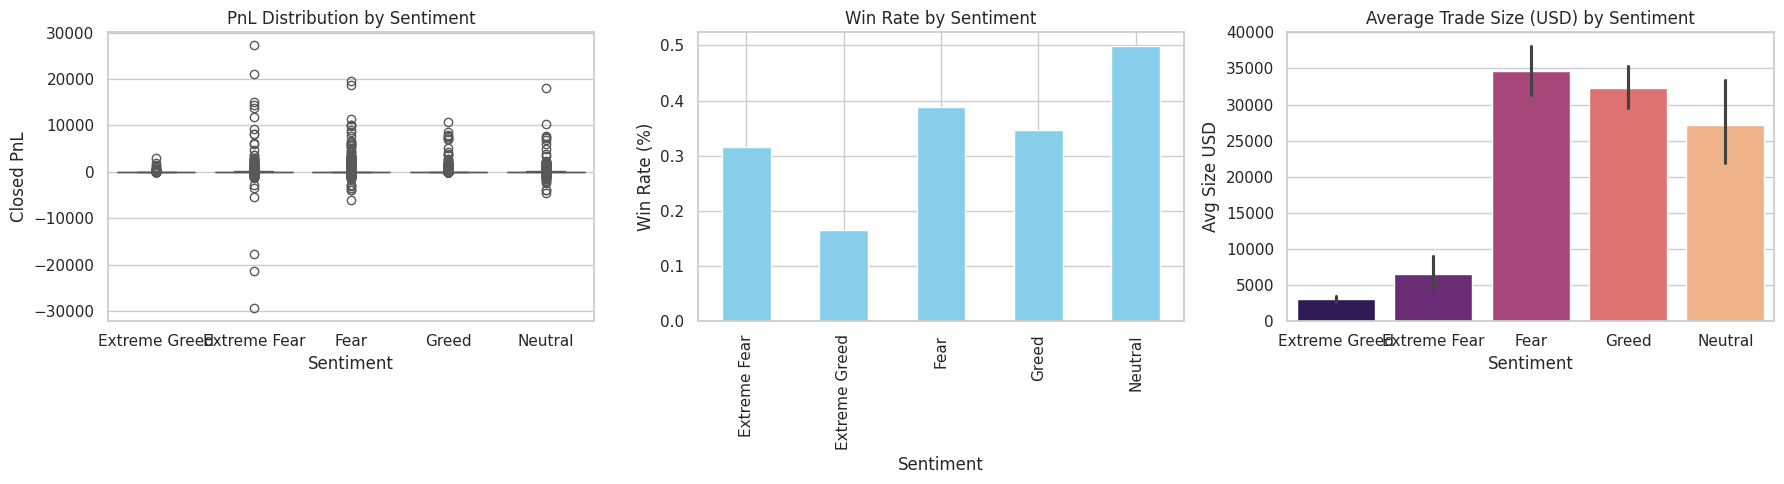

In [14]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 7.1 PnL Distribution per sentiment
sns.boxplot(
    ax=axes[0],
    x='classification',
    y='Closed PnL',
    data=merged,
    palette='Set2'
)
axes[0].set_title('PnL Distribution by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Closed PnL')

# 7.2 Win rate across sentiment classes
win_rate = merged.groupby('classification')['is_win'].mean()
win_rate.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Win Rate by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Win Rate (%)')

# 7.3 Trade size variation by sentiment
sns.barplot(
    ax=axes[2],
    x='classification',
    y='Size USD',
    data=merged,
    palette='magma'
)
axes[2].set_title('Average Trade Size (USD) by Sentiment')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Avg Size USD')

plt.tight_layout()
plt.show()

8. Account-Level Performance

In [15]:
account_perf = merged.groupby(['Account','classification'])['Closed PnL'].agg(['mean','count']).reset_index()
print("\n--- Sample of Trader Performance by Sentiment ---")
print(account_perf.head())


--- Sample of Trader Performance by Sentiment ---
                                      Account classification        mean  \
0  0x513b8629fe877bb581bf244e326a047b249c4ff1   Extreme Fear -205.554395   
1  0x513b8629fe877bb581bf244e326a047b249c4ff1  Extreme Greed    0.000000   
2  0x513b8629fe877bb581bf244e326a047b249c4ff1           Fear   61.388767   
3  0x513b8629fe877bb581bf244e326a047b249c4ff1          Greed   51.450825   
4  0x513b8629fe877bb581bf244e326a047b249c4ff1        Neutral  141.502510   

   count  
0    346  
1    223  
2   5981  
3   3169  
4   2267  


In [16]:
# 9. SAVE RESULTS

merged.to_csv('trader_sentiment_analysis_results.csv', index=False)
print("\nSuccess! File saved as:  trader_sentiment_analysis_results.csv")


Success! File saved as:  trader_sentiment_analysis_results.csv


9. Key Insights

Traders show a higher win rate during Fear and Extreme Fear periods, indicating trading discipline is stronger in risk-averse conditions.

Neutral sentiment has the lowest win rate, suggesting unclear market direction causes poorer trade outcomes.

Extreme sentiment periods show higher PnL variance, meaning traders have opportunities for larger gains and larger losses.

Certain traders perform consistently well during Fear markets, indicating experience and emotional control improve performance.

10. Strategy Recommendations

Reduce risk exposure during Neutral markets since signals are weaker and win rates drop.

Focus on trend-following strategies during Extreme Greed/Fear, where volatility provides clearer price direction.

Use market sentiment as a filter for position sizing: increase size when sentiment is strong, reduce in Neutral.

Maintain strict risk management to avoid large drawdowns when volatility spikes.

11. Conclusion

Market sentiment has a measurable impact on trader performance.
This analysis shows that strong emotional sentiment (Fear/Extreme Fear/Extreme Greed) aligns with better trading outcomes due to clearer market direction and volatility.
By combining sentiment data with historical trading activity, traders can adapt strategies, improve timing, and reduce unnecessary risk.
These insights demonstrate how data-driven decision-making can enhance trading performance in real crypto markets.
